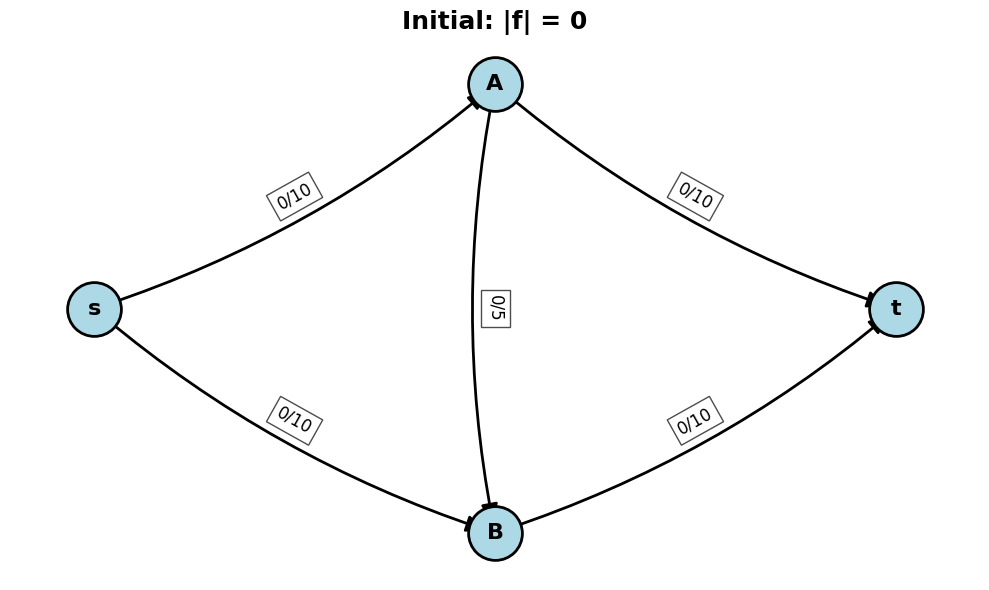

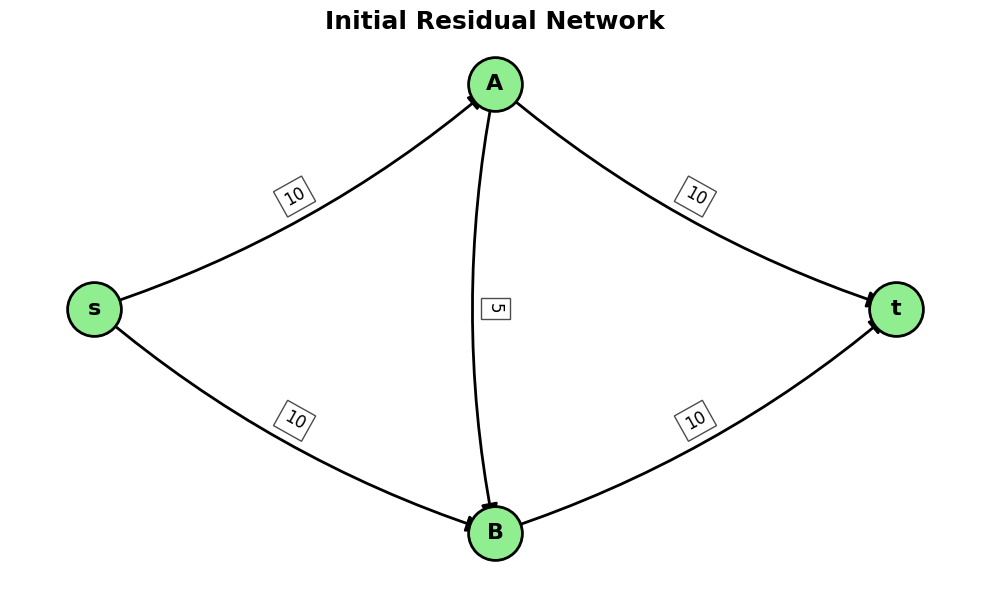

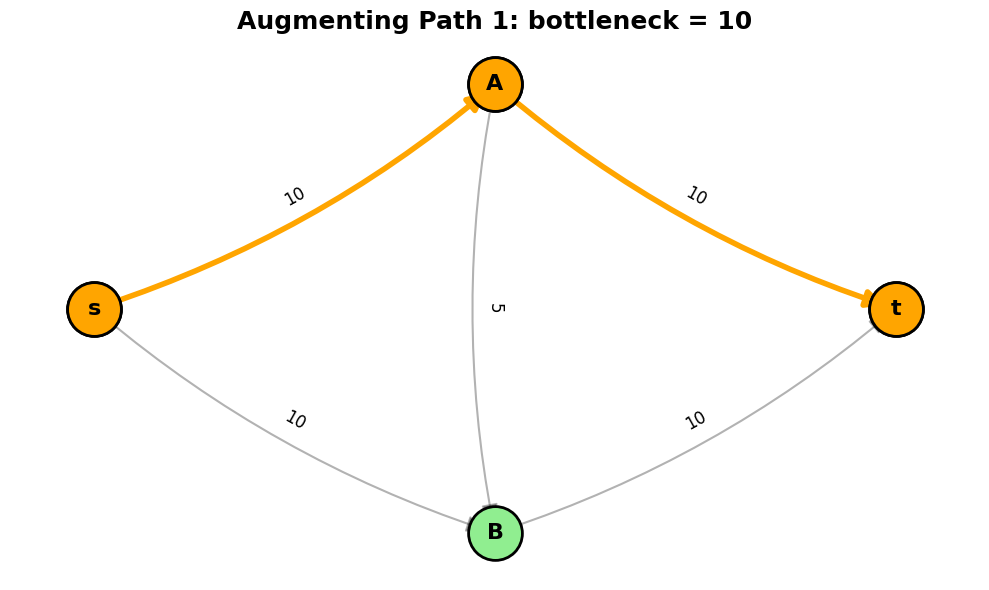

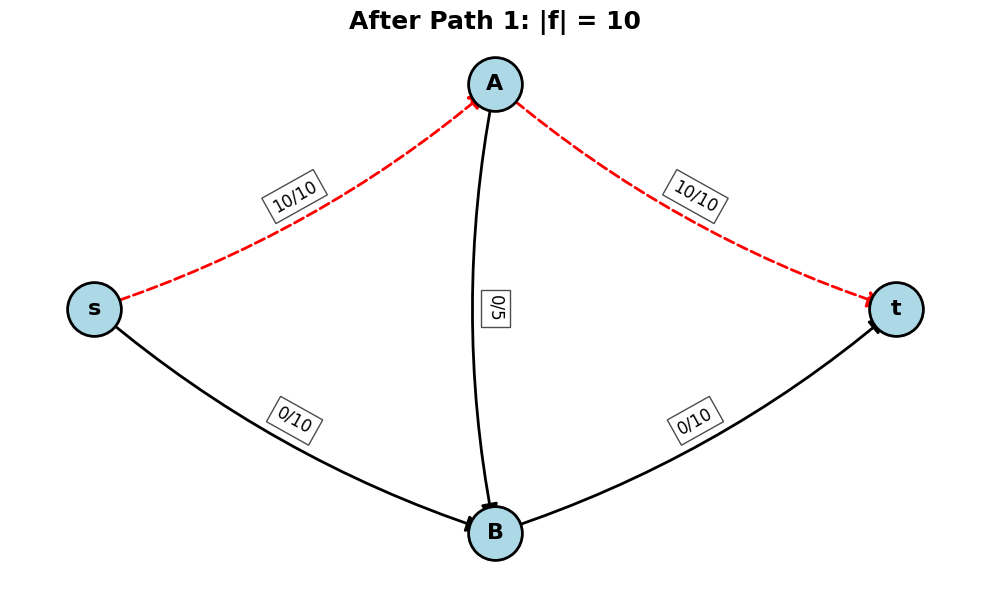

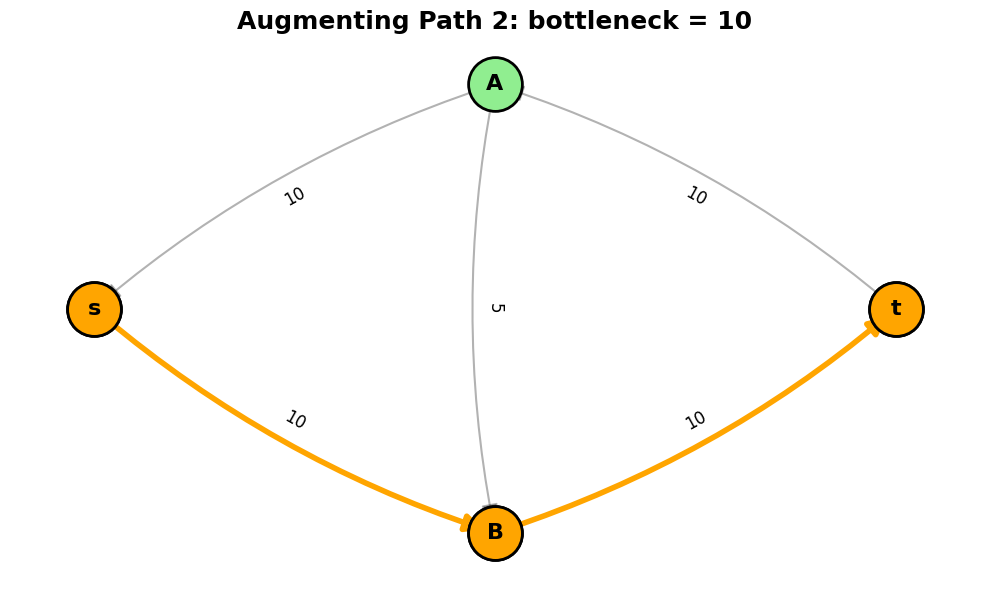

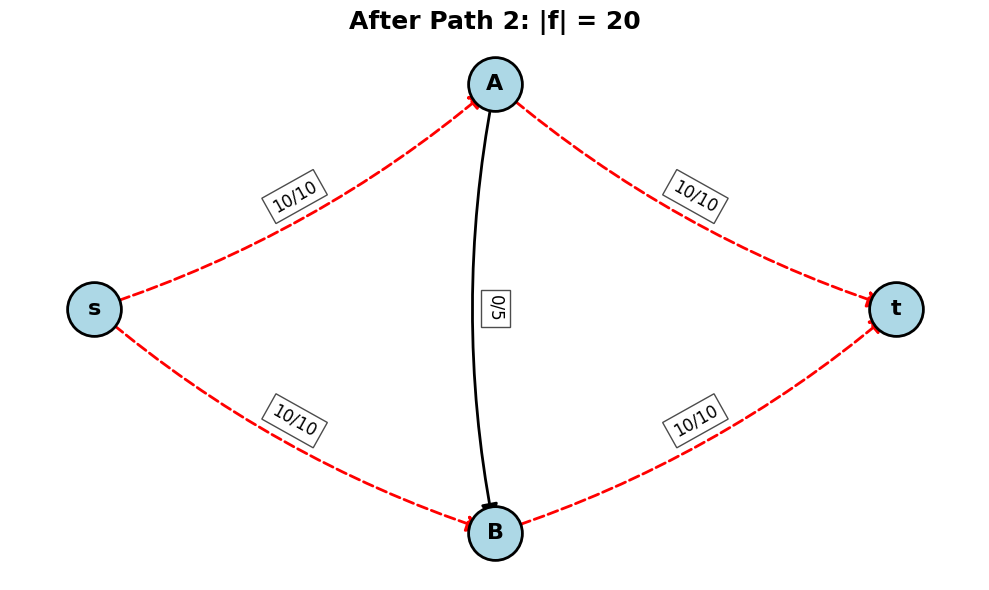

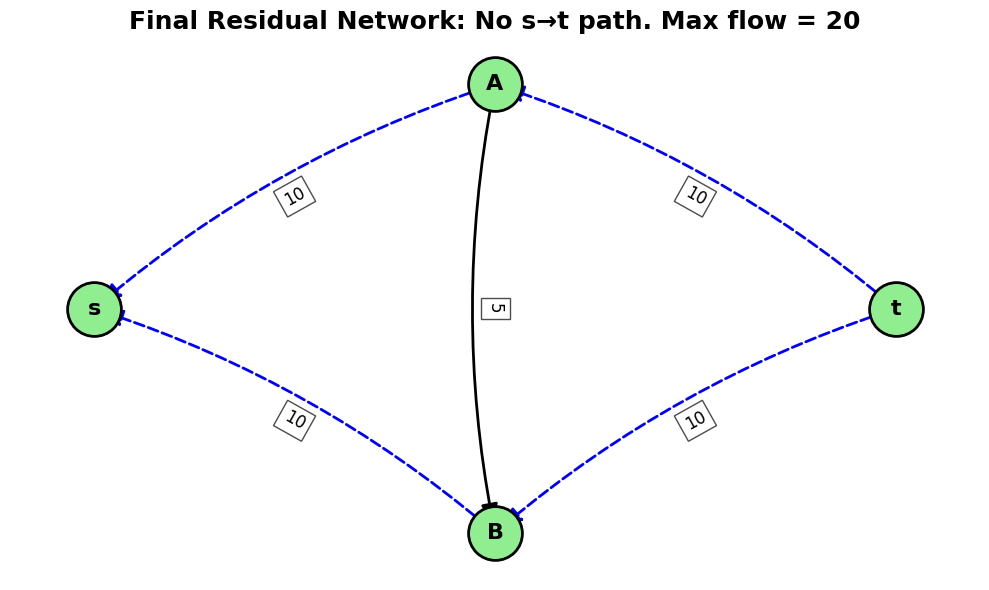

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_flow_network(edges, flows, pos=None, title="Flow Network"):
    """
    Draws the flow network with edges labeled as flow/capacity.
    Saturated edges are red dashed.

    edges: dict {(u,v): capacity}
    flows: dict {(u,v): flow}
    pos: dict {node: (x,y)} for consistent layout
    """
    G = nx.DiGraph()

    for (u, v), cap in edges.items():
        flow = flows.get((u, v), 0)
        G.add_edge(u, v, capacity=cap, flow=flow, label=f'{flow}/{cap}')

    if pos is None:
        pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(10, 6))

    nx.draw_networkx_nodes(G, pos, node_color='lightblue',
                           node_size=1500, edgecolors='black', linewidths=2)

    saturated = [(u, v) for u, v, d in G.edges(data=True)
                 if d['flow'] == d['capacity'] and d['capacity'] > 0]
    normal = [(u, v) for u, v, d in G.edges(data=True)
              if d['flow'] < d['capacity']]

    nx.draw_networkx_edges(G, pos, edgelist=normal, arrowsize=25,
                           width=2, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_edges(G, pos, edgelist=saturated, edge_color='red',
                           arrowsize=25, style='dashed', width=2,
                           connectionstyle='arc3,rad=0.1')

    nx.draw_networkx_labels(G, pos, font_size=16, font_weight='bold')
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=12,
                                 bbox=dict(alpha=0.7, facecolor='white'))

    plt.title(title, fontsize=18, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def draw_residual_network(edges, flows, pos=None, title="Residual Network"):
    """
    Builds and draws G_f. Forward edges are solid black,
    backward edges are blue dashed.
    """
    Gf = nx.DiGraph()

    # Forward residual edges: c(u,v) - f(u,v) > 0
    for (u, v), cap in edges.items():
        flow = flows.get((u, v), 0)
        residual = cap - flow
        if residual > 0:
            Gf.add_edge(u, v, residual=residual,
                        label=str(residual), kind='forward')

    # Backward edges: f(u,v) > 0 creates edge (v,u)
    for (u, v), flow in flows.items():
        if flow > 0:
            Gf.add_edge(v, u, residual=flow,
                        label=str(flow), kind='backward')

    if pos is None:
        pos = nx.spring_layout(Gf, seed=42)

    plt.figure(figsize=(10, 6))

    nx.draw_networkx_nodes(Gf, pos, node_color='lightgreen',
                           node_size=1500, edgecolors='black', linewidths=2)

    forward = [(u, v) for u, v, d in Gf.edges(data=True) if d['kind'] == 'forward']
    backward = [(u, v) for u, v, d in Gf.edges(data=True) if d['kind'] == 'backward']

    nx.draw_networkx_edges(Gf, pos, edgelist=forward, arrowsize=25,
                           width=2, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_edges(Gf, pos, edgelist=backward, arrowsize=25,
                           style='dashed', edge_color='blue', width=2,
                           connectionstyle='arc3,rad=0.1')

    nx.draw_networkx_labels(Gf, pos, font_size=16, font_weight='bold')
    edge_labels = nx.get_edge_attributes(Gf, 'label')
    nx.draw_networkx_edge_labels(Gf, pos, edge_labels, font_size=12,
                                 bbox=dict(alpha=0.7, facecolor='white'))

    plt.title(title, fontsize=18, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    return pos

def highlight_augmenting_path(edges, flows, path, pos=None, title="Augmenting Path in G_f"):
    """
    Draws residual network and highlights a specific augmenting path in orange.
    path: list of nodes like ['s','A','t']
    """
    Gf = nx.DiGraph()

    for (u, v), cap in edges.items():
        flow = flows.get((u, v), 0)
        residual = cap - flow
        if residual > 0:
            Gf.add_edge(u, v, residual=residual, label=str(residual))

    for (u, v), flow in flows.items():
        if flow > 0:
            Gf.add_edge(v, u, residual=flow, label=str(flow))

    if pos is None:
        pos = nx.spring_layout(Gf, seed=42)

    path_edges = list(zip(path, path[1:]))

    plt.figure(figsize=(10, 6))
    nx.draw_networkx_nodes(Gf, pos, node_color='lightgreen',
                           node_size=1500, edgecolors='black', linewidths=2)

    # Draw path nodes in orange
    nx.draw_networkx_nodes(Gf, pos, nodelist=path, node_color='orange',
                           node_size=1500, edgecolors='black', linewidths=2)

    other_edges = [e for e in Gf.edges() if e not in path_edges]
    nx.draw_networkx_edges(Gf, pos, edgelist=other_edges, arrowsize=25,
                           width=1.5, alpha=0.3, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_edges(Gf, pos, edgelist=path_edges, arrowsize=25,
                           width=4, edge_color='orange',
                           connectionstyle='arc3,rad=0.1')

    nx.draw_networkx_labels(Gf, pos, font_size=16, font_weight='bold')
    edge_labels = nx.get_edge_attributes(Gf, 'label')
    nx.draw_networkx_edge_labels(Gf, pos, edge_labels, font_size=12)

    plt.title(title, fontsize=18, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # network details
    edges = {
        ('s', 'A'): 10,
        ('s', 'B'): 10,
        ('A', 't'): 10,
        ('A', 'B'): 5,
        ('B', 't'): 10
    }

    # Fixed layout so s is left, t is right, looks clean for presenting
    pos = {'s': (0, 0), 'A': (1, 1), 'B': (1, -1), 't': (2, 0)}

    # Step 0: Initial state
    flows_0 = {}
    draw_flow_network(edges, flows_0, pos, "Initial: |f| = 0")
    draw_residual_network(edges, flows_0, pos, "Initial Residual Network")
    highlight_augmenting_path(edges, flows_0, ['s','A','t'], pos,
                              "Augmenting Path 1: bottleneck = 10")

    # Step 1: After s->A->t with flow 10
    flows_1 = {('s','A'): 10, ('A','t'): 10}
    draw_flow_network(edges, flows_1, pos, "After Path 1: |f| = 10")
    highlight_augmenting_path(edges, flows_1, ['s','B','t'], pos,
                              "Augmenting Path 2: bottleneck = 10")

    # Step 2: After s->B->t with flow 10
    flows_2 = {('s','A'): 10, ('A','t'): 10, ('s','B'): 10, ('B','t'): 10}
    draw_flow_network(edges, flows_2, pos, "After Path 2: |f| = 20")
    draw_residual_network(edges, flows_2, pos,
                          "Final Residual Network: No s→t path. Max flow = 20")

    # To use with your own network, just change 'edges', 'flows', and 'pos'
    # Example for the water distribution problem:
    # edges = {('s','X'):8, ('s','Z'):7, ('X','Y'):5, ('X','Z'):4,
    #          ('Y','t'):6, ('Z','Y'):3, ('Z','t'):9}
    # pos = {'s':(0,0), 'X':(1,1), 'Z':(1,-1), 'Y':(2,0.5), 't':(3,0)}
    # flows = {('s','X'):6, ('s','Z'):7, ('X','Y'):5, ('X','Z'):1,
    #          ('Y','t'):6, ('Z','Y'):1, ('Z','t'):7}

Max flow = 150


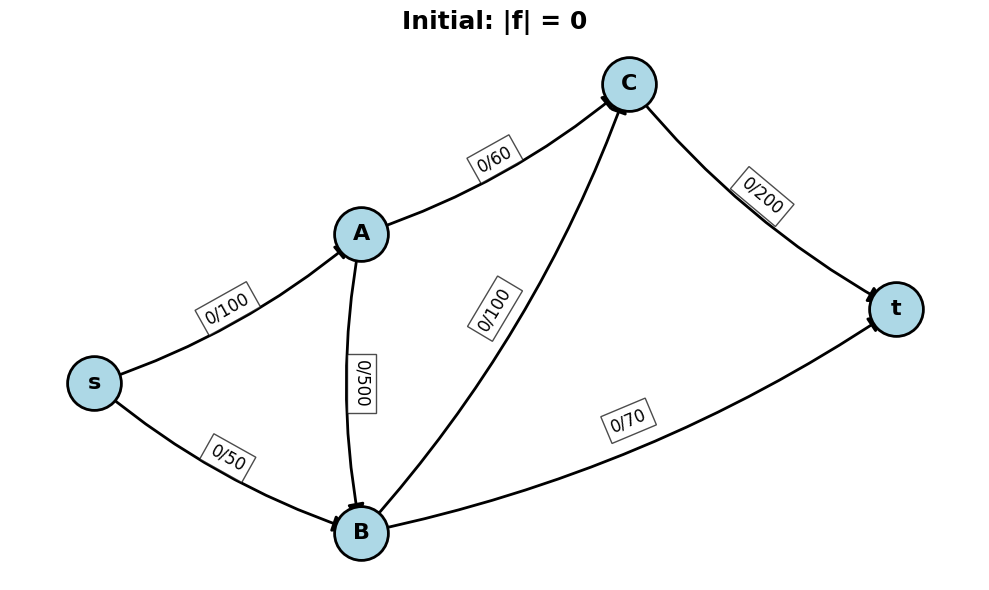

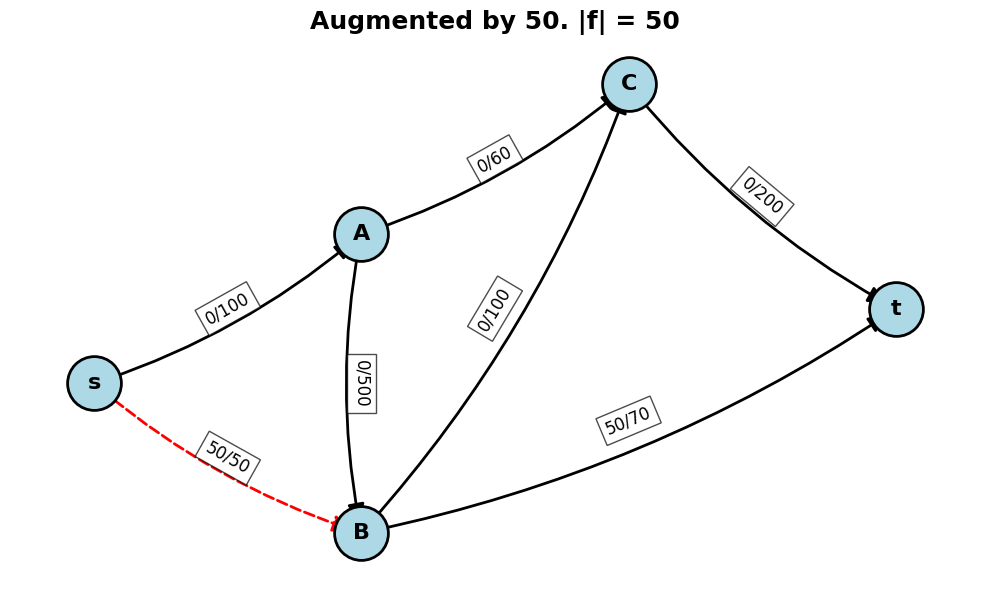

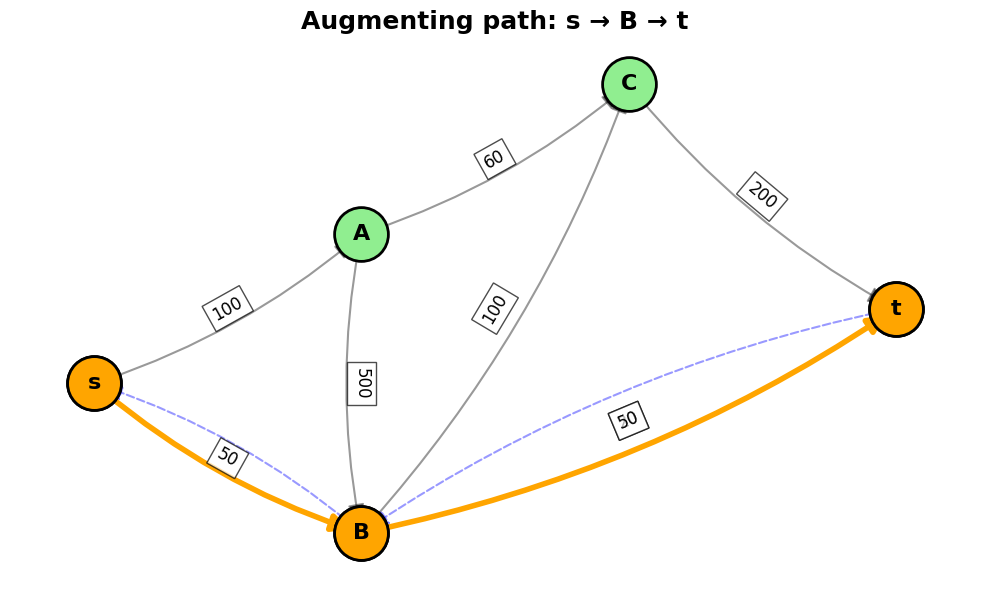

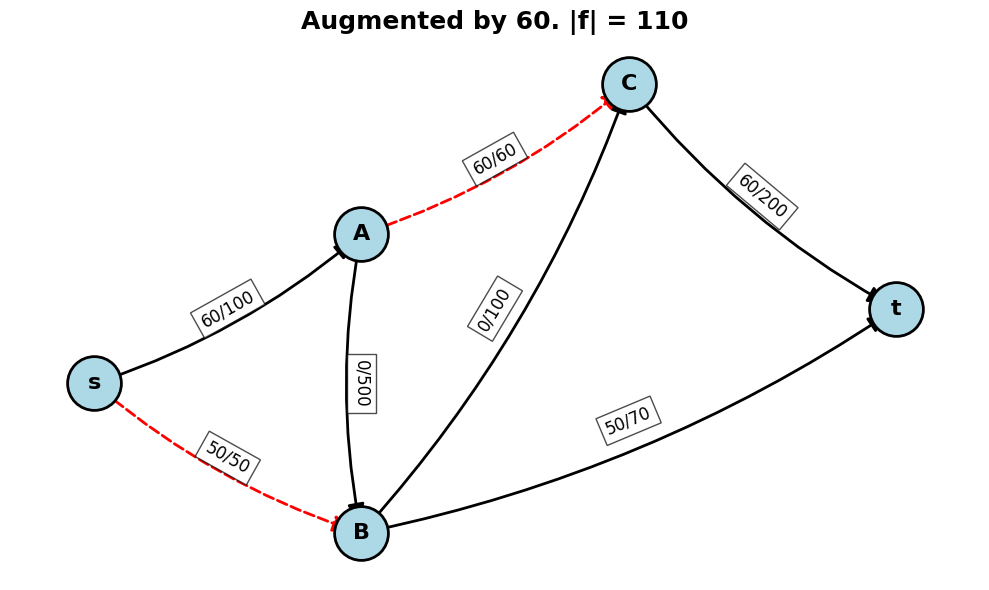

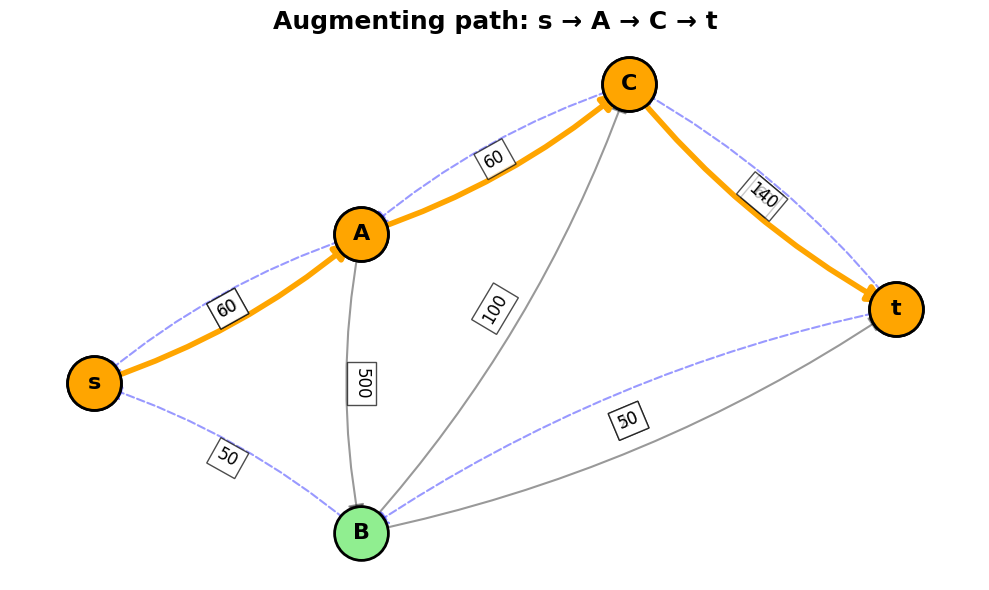

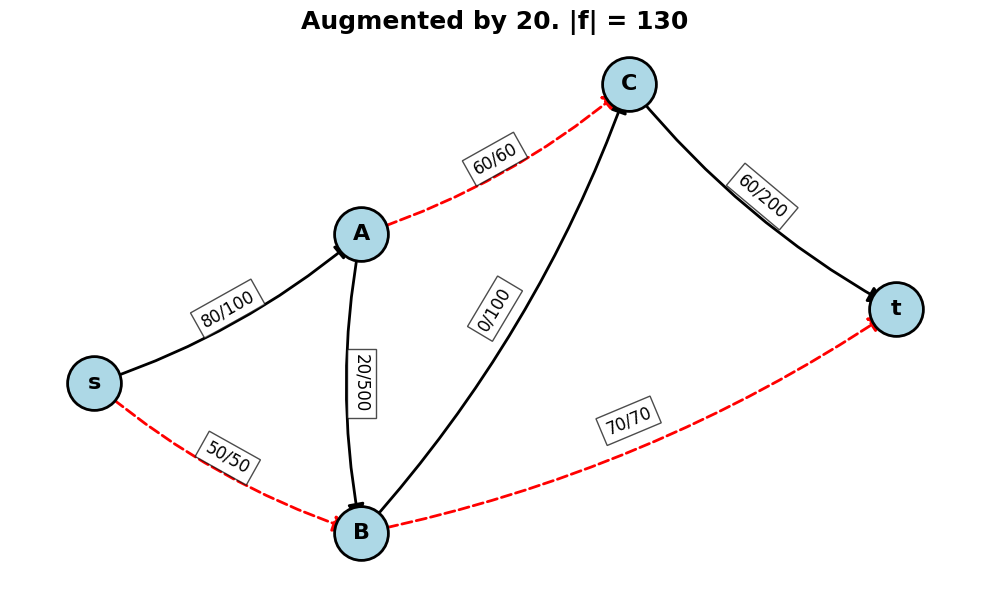

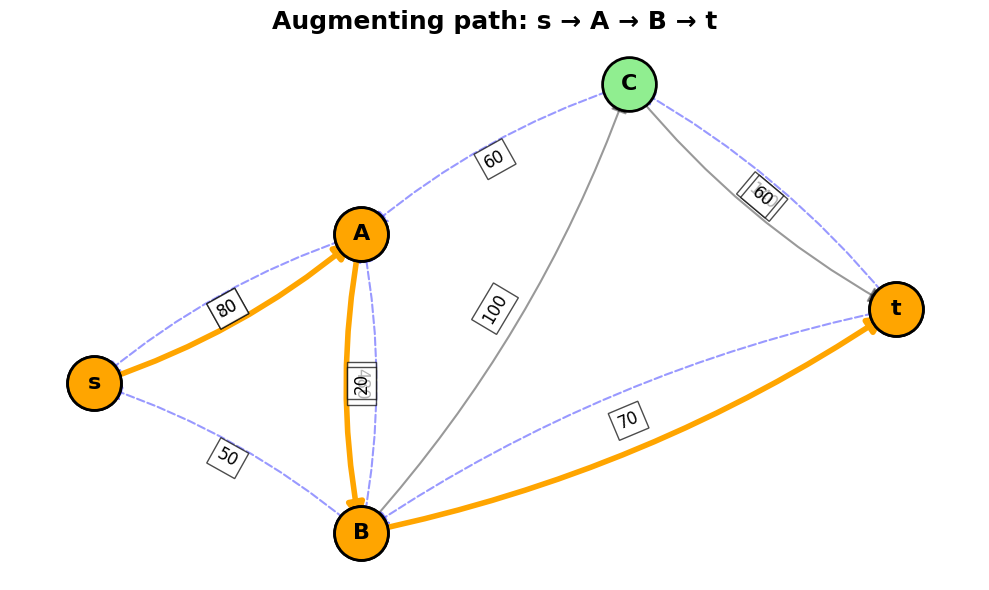

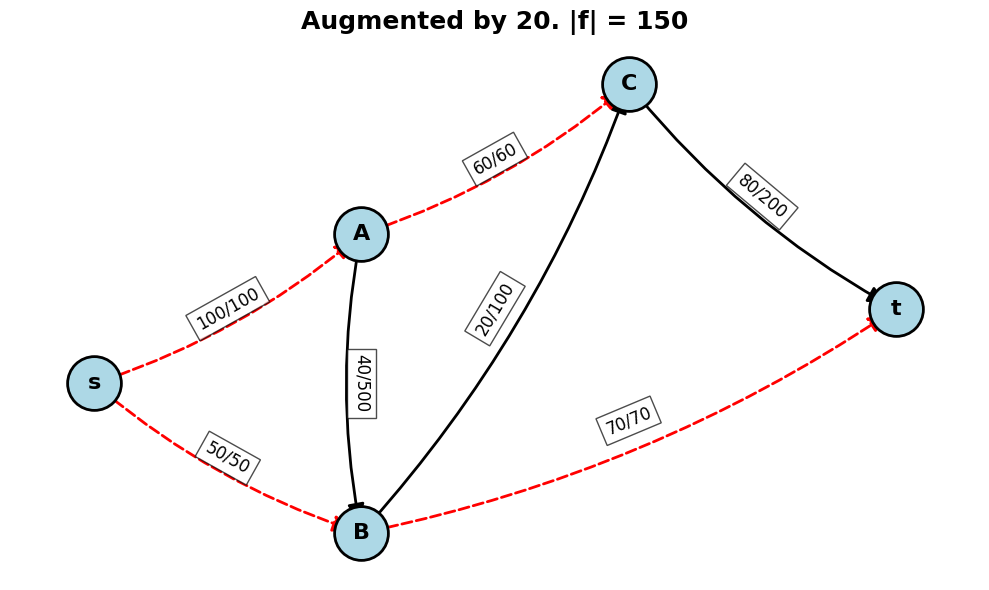

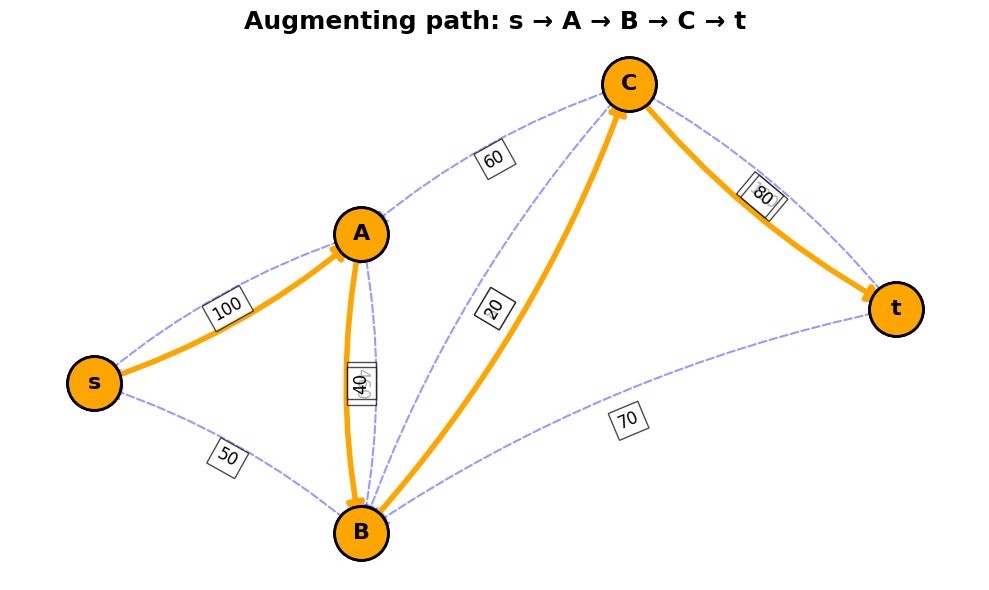

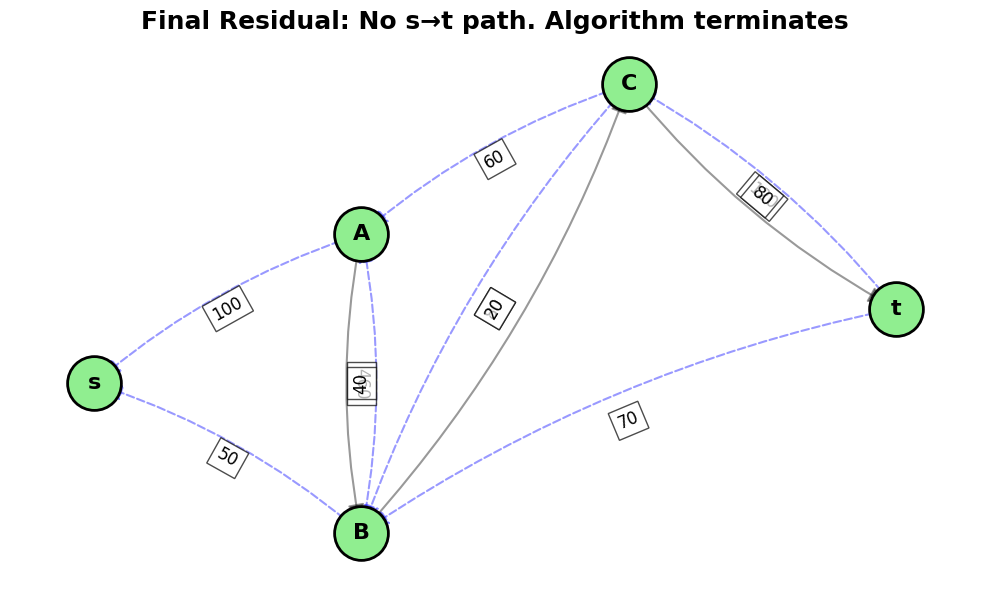

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

def bfs_find_path(residual_graph, s, t, parent):
    """BFS to find shortest augmenting path in G_f. Returns True if path exists."""
    visited = set()
    queue = deque([s])
    visited.add(s)

    while queue:
        u = queue.popleft()
        for v in residual_graph[u]:
            cap = residual_graph[u][v]
            if v not in visited and cap > 0:
                visited.add(v)
                parent[v] = u
                if v == t:
                    return True
                queue.append(v)
    return False

def ford_fulkerson(edges, s='s', t='t'):
    """
    Runs Edmonds-Karp. Returns final flows dict and list of steps for viz.
    edges: dict {(u,v): capacity}
    """
    # Initialize flows and residual graph
    flows = {edge: 0 for edge in edges}
    residual = {}
    nodes = set([u for u, v in edges] + [v for u, v in edges])

    for u in nodes:
        residual[u] = {}
    for (u, v), cap in edges.items():
        residual[u][v] = cap
        if v not in residual:
            residual[v] = {}
        residual[v][u] = 0 # backward edge

    parent = {}
    max_flow = 0
    steps = [(flows.copy(), f"Initial: |f| = 0")] # for visualization

    # Augment while path exists
    while bfs_find_path(residual, s, t, parent):
        # Find bottleneck
        path_flow = float('inf')
        v = t
        path_nodes = [t]
        while v!= s:
            u = parent[v]
            path_flow = min(path_flow, residual[u][v])
            v = u
            path_nodes.append(v)
        path_nodes.reverse()

        # Update residual capacities
        v = t
        while v!= s:
            u = parent[v]
            residual[u][v] -= path_flow
            residual[v][u] += path_flow
            v = u

        # Update flows dict for original edges only
        v = t
        while v!= s:
            u = parent[v]
            if (u, v) in edges: # forward edge
                flows[(u, v)] += path_flow
            elif (v, u) in edges: # backward edge, so we reduced flow
                flows[(v, u)] -= path_flow
            v = u

        max_flow += path_flow
        steps.append((flows.copy(), f"Augmented by {path_flow}. |f| = {max_flow}"))
        steps.append((flows.copy(), path_nodes)) # store path for highlighting

    return flows, max_flow, steps

def draw_flow_network(edges, flows, pos=None, title="Flow Network"):
    G = nx.DiGraph()
    for (u, v), cap in edges.items():
        flow = flows.get((u, v), 0)
        G.add_edge(u, v, capacity=cap, flow=flow, label=f'{flow}/{cap}')

    if pos is None:
        pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(10, 6))
    nx.draw_networkx_nodes(G, pos, node_color='lightblue',
                           node_size=1500, edgecolors='black', linewidths=2)

    saturated = [(u, v) for u, v, d in G.edges(data=True)
                 if d['flow'] == d['capacity'] and d['capacity'] > 0]
    normal = [(u, v) for u, v, d in G.edges(data=True)
              if d['flow'] < d['capacity']]

    nx.draw_networkx_edges(G, pos, edgelist=normal, arrowsize=25,
                           width=2, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_edges(G, pos, edgelist=saturated, edge_color='red',
                           arrowsize=25, style='dashed', width=2,
                           connectionstyle='arc3,rad=0.1')

    nx.draw_networkx_labels(G, pos, font_size=16, font_weight='bold')
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=12,
                                 bbox=dict(alpha=0.7, facecolor='white'))

    plt.title(title, fontsize=18, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def draw_residual_network(edges, flows, pos=None, title="Residual Network", highlight_path=None):
    Gf = nx.DiGraph()
    for (u, v), cap in edges.items():
        flow = flows.get((u, v), 0)
        residual = cap - flow
        if residual > 0:
            Gf.add_edge(u, v, residual=residual, label=str(residual), kind='forward')

    for (u, v), flow in flows.items():
        if flow > 0:
            Gf.add_edge(v, u, residual=flow, label=str(flow), kind='backward')

    if pos is None:
        pos = nx.spring_layout(Gf, seed=42)

    plt.figure(figsize=(10, 6))
    nx.draw_networkx_nodes(Gf, pos, node_color='lightgreen',
                           node_size=1500, edgecolors='black', linewidths=2)

    if highlight_path:
        nx.draw_networkx_nodes(Gf, pos, nodelist=highlight_path,
                               node_color='orange', node_size=1500,
                               edgecolors='black', linewidths=2)
        path_edges = list(zip(highlight_path, highlight_path[1:]))
    else:
        path_edges = []

    forward = [(u, v) for u, v, d in Gf.edges(data=True)
               if d['kind'] == 'forward' and (u, v) not in path_edges]
    backward = [(u, v) for u, v, d in Gf.edges(data=True)
                if d['kind'] == 'backward' and (u, v) not in path_edges]

    nx.draw_networkx_edges(Gf, pos, edgelist=forward, arrowsize=25,
                           width=1.5, alpha=0.4, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_edges(Gf, pos, edgelist=backward, arrowsize=25,
                           style='dashed', edge_color='blue', width=1.5,
                           alpha=0.4, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_edges(Gf, pos, edgelist=path_edges, arrowsize=25,
                           width=4, edge_color='orange',
                           connectionstyle='arc3,rad=0.1')

    nx.draw_networkx_labels(Gf, pos, font_size=16, font_weight='bold')
    edge_labels = nx.get_edge_attributes(Gf, 'label')
    nx.draw_networkx_edge_labels(Gf, pos, edge_labels, font_size=12,
                                 bbox=dict(alpha=0.7, facecolor='white'))

    plt.title(title, fontsize=18, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":

    edges = {
        ('s', 'A'): 100,
        ('s', 'B'): 50,
        ('A', 'C'): 60,
        ('A', 'B'): 500,
        ('B', 't'): 70,
        ('C', 't'): 200,
        ('B', 'C'): 100
        # change edges' details and add more edges, or remove existing edges as needed
    }
    pos = {'s': (0, 0), 'A': (1, 1), 'B': (1, -1), 'C': (2, 2), 't': (3, .5)}
    # change pos dictionary values depending on the edges chosen, so that the graph looks legible.

    final_flows, max_flow, steps = ford_fulkerson(edges, 's', 't')

    print(f"Max flow = {max_flow}")

    # Draw every step
    for i, step in enumerate(steps):
        if isinstance(step[1], str): # it's a flow state with title
            flows, title = step
            draw_flow_network(edges, flows, pos, title)
        else: # it's a path to highlight
            flows, path = step
            draw_residual_network(edges, flows, pos,
                                  f"Augmenting path: {' → '.join(path)}",
                                  highlight_path=path)

    # Final residual network
    draw_residual_network(edges, final_flows, pos,
                          "Final Residual: No s→t path. Algorithm terminates")